# Getting started with Megamicros objects

The `Megamicros` class is the base class for all *Megamicros* usb antennas. 
This Notebook shows how you can use the `Megamicros` interface provided you have a *Megamicros* device connected on your USB port.

Beware that you need to have `libusb` installed, both the python interface and the C libusb.1.0.26 library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from megamicros_tools.log import log
from megamicros.core.mu import Megamicros

log.setLevel( "INFO" )

## Check Usb device and Megamicros device

In [ ]:
Megamicros.check_device()
Megamicros.selfest()

## Declare your antenna object

The ``Megamicros`` constructor needs no argument. The device is detected and the class device parameters are populated.

In [ ]:
# Define an empty antenna
antenna = Megamicros()

Lets know some properties of the connected antenna:

In [ ]:
print( f"Available MEMs = {antenna.available_mems}" )
print( f"Available analogs = {antenna.available_analogs}" )
print( f"System type = {antenna.system_type}" )

Try 1s of acquisition on all available MEMs

In [ ]:
antenna.run( 
    duration=1, 
    mems = [0, 1],
    counter=False, 
    counter_skip=False, 
    status=False,
    datatype = 'int32',
    sampling_frequency=50000
)

# Wait until the thread terminates
antenna.wait()

One can force some MEMs to be available while they actually are not. 
Corresponding channels will stay at 0.

In [ ]:
antenna.setAvailableMems( [i for i in range(32)] )

antenna.run( 
    duration=1, 
    mems = [0, 10],
    counter=False, 
    counter_skip=False, 
    status=False,
    datatype = 'int32',
    sampling_frequency=50000
)

antenna.wait()


Getting data can be done by iterate through the `antenna` object provided the antenna had already recived all the data:

In [ ]:
# get data
for data in antenna:
    print( f"data={data}" )

The previous method suggests that real time is not possible.
Actually, you can perform real time acqusition if you iterate before calling the `wait` method, just after the `run` call:   

In [ ]:
import time

antenna.run( 
    duration=1, 
    mems = [0, 1],
    counter=False, 
    counter_skip=False, 
    status=False,
    sampling_frequency=50000
)

# get data
start_time = time.time()
for data in antenna:
    print( f"data={data}" )

print( f"Elapsed time= {time.time() - start_time}" )

# Wait until the thread terminates
antenna.wait()

Note that the elapsed time reaches 4 seconds, whereas the requested acquisition time was 1 second.
Moreover, the system message reported 0.94s.

This is because the system's time measurement method is more accurate: it only includes the actual acquisition time.

The user method, as reported above, includes, in addition to the acquisition:
* The MEMs initialization delay (MEMs powering), default is 1 second
* The timeout delay to leave the queue (2 seconds)
As a consequence, the total elapsed is 4 secondes.

## Plots

See the `mu_graph.py` example in the èxamples` directory

## Saving data in H5 file

In [ ]:
# Define an empty antenna
antenna = Megamicros()

# Set all MEMs as available
antenna.setAvailableMems( [i for i in range(32)] )

antenna.run( 
    duration=3, 
    mems = [0, 1, 2, 3, 4, 5, 6, 7],
    counter=False, 
    counter_skip=False, 
    status=False,
    sampling_frequency=10000,
    h5_recording=True,                          # H5 recording ON
    h5_rootdir='./',                            # directory where to save file
    h5_filename='test.h5',                      # filename
)

antenna.wait()

### Control the H5 file created

We can control easily the H5 file generated by building a new antenna with this H5 file as input. 

In [2]:
from megamicros.core.h5 import MemsArrayH5

# Define the antenna
antenna_h5 = MemsArrayH5( 
    filename='test.h5',
)

print( f"Sampling frequency: {antenna_h5.sampling_frequency}Hz" )
print( f"Channels number: {antenna_h5.mems_number}" )
print( f"Available MEMs number: {antenna_h5.available_mems_number}" )
print( f"Available MEMs: {antenna_h5.available_mems}" )
print( f"Whether counter is available or not: {antenna_h5.counter}" )
print( f"Dataset(s) number: " + str(antenna_h5.dataset_number) )


2024-04-04 18:36:03,618 [INFO]:  .Install MemsArrayH5 settings
2024-04-04 18:36:03,619 [INFO]:  .Created a new antenna
2024-04-04 18:36:03,621 [INFO]:  .Found test.h5 MuH5 file
2024-04-04 18:36:03,623 [INFO]:  .Set 8 available MEMs numbered from 0 to 7
2024-04-04 18:36:03,624 [INFO]:  .No analogic channels available


Sampling frequency: 10000.0Hz
Channels number: 0
Available MEMs number: 8
Available MEMs: [0, 1, 2, 3, 4, 5, 6, 7]
Whether counter is available or not: False
Dataset(s) number: 3


### Plot signals

In [3]:
# Reinit the antenna
antenna_h5 = MemsArrayH5( 
    filename='test.h5',
)

# Choose MEMS to plot
MEMS = [0, 1]

# Init a np.ndarray
signals = np.ndarray( (0, len(MEMS) ) )

# Run the H5 antenna
antenna_h5.run( 
    duration=1, 
    mems = MEMS,
    real_time=False,
)

# Get signals
for data in antenna_h5:
    print( f"data shape={np.shape(data)}")
    signals = np.concatenate( ( signals, data ), axis=0 )

# waiting for the end of the running thread is mandatory
antenna_h5.wait()
print( f"exit from loop. Signal shape is: {np.shape( signals )}" )

2024-04-04 18:36:09,194 [INFO]:  .Install MemsArrayH5 settings
2024-04-04 18:36:09,195 [INFO]:  .Created a new antenna
2024-04-04 18:36:09,197 [INFO]:  .Found test.h5 MuH5 file
2024-04-04 18:36:09,199 [INFO]:  .Set 8 available MEMs numbered from 0 to 7
2024-04-04 18:36:09,199 [INFO]:  .No analogic channels available
2024-04-04 18:36:09,200 [INFO]:  .Starting run execution
2024-04-04 18:36:09,200 [INFO]:  .Install MemsArray settings
2024-04-04 18:36:09,201 [INFO]:  .2 MEMs were activated among 0 to 7 available MEMs
2024-04-04 18:36:09,202 [INFO]:  .Install MemsArrayH5 settings
2024-04-04 18:36:09,202 [INFO]:  .Pre-execution checks for MemsArray object
2024-04-04 18:36:09,202 [INFO]:  .Counter skipping not set -> set to False
2024-04-04 18:36:09,203 [INFO]:  .Pre-execution checks for MemsArrayH5 object
2024-04-04 18:36:09,203 [INFO]:  .Perform a 1s run loop
2024-04-04 18:36:09,203 [INFO]:  .Frame length: 256 samples (chunk size: 2048 Bytes)
2024-04-04 18:36:09,203 [INFO]:  .Sampling freq

data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
data shape=(256, 2)
exit from loop. Signal shape is: (9984, 2)


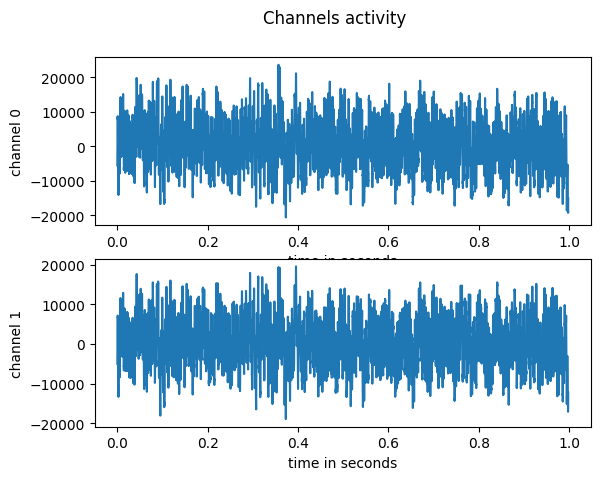

In [4]:
# plot signals
time = np.array( range( np.size(signals,0) ) )/antenna_h5.sampling_frequency
#time = np.array( range( 1000 ) )/antenna_h5.sampling_frequency
fig, axs = plt.subplots( antenna_h5.channels_number )
fig.suptitle('Channels activity')	
for s in range( antenna_h5.channels_number ):
    axs[s].plot( time, signals[:len(time),s] )
    axs[s].set( xlabel='time in seconds', ylabel='channel %d' % s )

plt.show()